In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
from pathlib import Path
PROJECT_ROOT = Path.cwd()

RESULTS_DIR = PROJECT_ROOT / "results"

In [3]:
from analysis.sparsity_analysis import collect_sparsity_for_n, summarize_multi_runs_sparsity_for_multi_keys


In [4]:
from pathlib import Path
import re
PROJECT_ROOT = Path.cwd()
RESULTS_DIR = PROJECT_ROOT / "results"

from tasks.tasks_using import make_batch_mtstyle_dms, make_batch_mtstyle_parity
from analysis.sparsity_analysis import collect_sparsity_for_n, summarize_multi_runs_sparsity_for_multi_keys

def make_network_paths(base_dir, pattern):
    base_dir = RESULTS_DIR / base_dir
    glob_pattern = pattern.format(i="*")
    matches = sorted(
        base_dir.glob(glob_pattern),
        key=lambda p: int(re.search(r"network_(\d+)", p.name).group(1)),
    )
    return [str(p) for p in matches]

RUN_GROUPS = {
    ("dms", "simultaneous"): {
        "paths": make_network_paths(
            "single_task/dms_multistyle_repeats",
            "single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}",
        ),
        "batch_fn": make_batch_mtstyle_dms,
    }}


RUN_GROUPS_PARITY = {
    ("parity", "simultaneous"): {
        "paths": make_network_paths(
            "single_task/parity_multistyle_repeats",
            "single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_{i}",
        ),
        "batch_fn": make_batch_mtstyle_parity,
    }}

In [ ]:
sparsity_df = summarize_multi_runs_sparsity_for_multi_keys(
    run_paths=RUN_GROUPS[("dms", "simultaneous")]["paths"],
    batch_fn=RUN_GROUPS[("dms", "simultaneous")]["batch_fn"],
    keys=("gc",),  # or e.g. ("gc", "hidden") for more populations
)


Processing run 1/8: single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1
(4096, 256)
(4864, 256)
(7168, 256)
(9792, 256)
(10176, 256)
(12032, 256)
(13248, 256)
(14976, 256)
(20096, 256)
(16256, 256)
(16320, 256)
(24448, 256)
(25536, 256)
(28992, 256)
(29952, 256)
(30016, 256)
(32768, 256)
(37632, 256)
(35712, 256)
(33856, 256)
(35712, 256)
(37376, 256)
(46784, 256)
(40320, 256)
(49920, 256)
(44864, 256)
(54336, 256)
(47424, 256)
(41920, 256)
(56256, 256)
(47616, 256)
(59712, 256)
(44480, 256)
Processing run 2/8: single_dms_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_2
(4544, 256)
(5312, 256)
(7168, 256)
(9408, 256)
(12224, 256)
(13504, 256)
(11328, 256)
(15232, 256)
(17536, 256)
(22144, 256)
(19392, 256)
(23744, 256)
(21376, 256)
(26496, 256)
(24832, 256)
(24192, 256)
(31744, 256)
(30208, 256)
(28224, 256)
(32256, 256)
(39744, 256)
(45248, 256)
(35520, 256)
(47296, 256)
(41728, 256)
(38528, 256)
(43200, 256)
(52160, 256)
(46720, 256)
(52864

In [ ]:
sparsity_df_parity = summarize_multi_runs_sparsity_for_multi_keys(
    run_paths=RUN_GROUPS_PARITY[("parity", "simultaneous")]["paths"],
    batch_fn=RUN_GROUPS_PARITY[("parity", "simultaneous")]["batch_fn"],
    keys=("gc",),  # or e.g. ("gc", "hidden") for more populations
)


Processing run 1/8: single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_1
(4032, 256)
(7104, 256)
(6848, 256)
(8576, 256)
(10816, 256)
(10752, 256)
(15680, 256)
(14976, 256)
(16000, 256)
(18496, 256)
(18496, 256)
(23488, 256)
(24000, 256)
(21248, 256)
(23552, 256)
(27264, 256)
(31296, 256)
Processing run 2/8: single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_2
(3712, 256)
(6016, 256)
(6976, 256)
(8064, 256)
(9664, 256)
(14272, 256)
(12928, 256)
(13504, 256)
(16896, 256)
(20480, 256)
(19200, 256)
(23936, 256)
(29248, 256)
(21056, 256)
(28608, 256)
(22976, 256)
(30144, 256)
Processing run 3/8: single_parity_elman_size_64_CB_gc256_RNNlr0.01_CBlr0.01_CBinput_simult_network_3
(4288, 256)
(5760, 256)
(6016, 256)
(10560, 256)
(10304, 256)
(14848, 256)
(13312, 256)
(13440, 256)
(17344, 256)
(20672, 256)
(20032, 256)
(22464, 256)
(23360, 256)
(26752, 256)
(26112, 256)
(26176, 256)
(33024, 256)
Processing run 4/8: single_parity_elman_size_6

In [ ]:
avg_sparsity_df = (
    sparsity_df
    .groupby(["population", "N"], as_index=False)
    .agg(
        population_sparseness_mean=("population_sparseness", "mean"),
        population_sparseness_sem=("population_sparseness", "sem"),
        lifetime_sparseness_mean=("lifetime_sparseness", "mean"),
        lifetime_sparseness_sem=("lifetime_sparseness", "sem"),
    )
)

avg_sparsity_df_parity = (
    sparsity_df_parity
    .groupby(["population", "N"], as_index=False)
    .agg(
        population_sparseness_mean=("population_sparseness", "mean"),
        population_sparseness_sem=("population_sparseness", "sem"),
        lifetime_sparseness_mean=("lifetime_sparseness", "mean"),
        lifetime_sparseness_sem=("lifetime_sparseness", "sem"),
    )
)

Population sparseness — freeze time at one input. Of the 256 GC units, how many are actually firing? A high score means a given input activates a small subset of units while the rest sit near zero — a sparse, "few active neurons per pattern" code. This is the instantaneous/per-input view.

Lifetime sparseness — freeze on one unit, look across all the inputs you tested it on. Does this unit fire for almost everything (broadly tuned, low score) or only for a narrow slice of inputs (selective, high score)? This is the per-unit tuning view.

They can come apart: you could have high population sparseness (few units active at any moment) built from units that each still respond to many different inputs across time, just not simultaneously — that would give low lifetime sparseness despite high population sparseness. For the classic Marr-Albus pattern-separation story to hold, you generally want both high: few active granule cells per input (population), and those cells being narrow feature-conjunction detectors rather than generalists (lifetime). If you find high population but low lifetime sparseness, that's actually an interesting and reportable nuance — it would mean the network is exploiting sparsity for efficiency without individual units doing real feature selection.

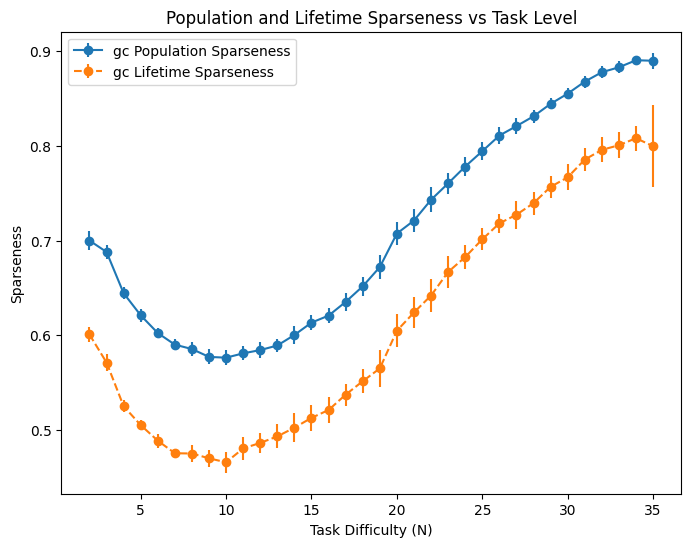

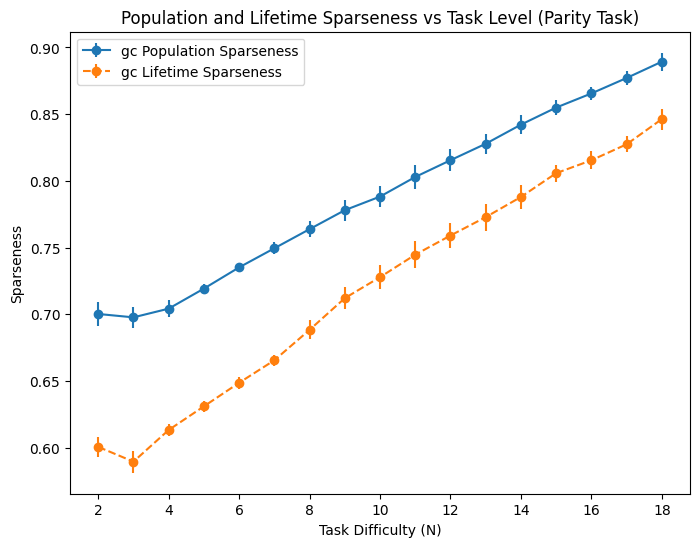

In [ ]:
# Plotting the results
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 6))
for population in avg_sparsity_df["population"].unique():
    pop_data = avg_sparsity_df[avg_sparsity_df["population"] == population]
    ax.errorbar(
        pop_data["N"],
        pop_data["population_sparseness_mean"],
        yerr=pop_data["population_sparseness_sem"],
        label=f"{population} Population Sparseness",
        fmt='-o'
    )
    ax.errorbar(
        pop_data["N"],
        pop_data["lifetime_sparseness_mean"],
        yerr=pop_data["lifetime_sparseness_sem"],
        label=f"{population} Lifetime Sparseness",
        fmt='--o'
    )
ax.set_xlabel("Task Difficulty (N)")
ax.set_ylabel("Sparseness")
ax.set_title("Population and Lifetime Sparseness vs Task Level")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
for population in avg_sparsity_df_parity["population"].unique():
    pop_data = avg_sparsity_df_parity[avg_sparsity_df_parity["population"] == population]
    ax.errorbar(
        pop_data["N"],
        pop_data["population_sparseness_mean"],
        yerr=pop_data["population_sparseness_sem"],
        label=f"{population} Population Sparseness",
        fmt='-o'
    )
    ax.errorbar(
        pop_data["N"],
        pop_data["lifetime_sparseness_mean"],
        yerr=pop_data["lifetime_sparseness_sem"],
        label=f"{population} Lifetime Sparseness",
        fmt='--o'
    )
ax.set_xlabel("Task Difficulty (N)")
ax.set_ylabel("Sparseness")
ax.set_title("Population and Lifetime Sparseness vs Task Level (Parity Task)")
ax.legend()
plt.show()

# Testing RNN-RNN 

In [5]:
from analysis.rebuild_model_utils import load_run_config
from training.save import match_aux_hidden_size,count_params
def get_cb_target_params(run_path):
    cfg = load_run_config(run_path)
    return cfg["params"]["cb"]["trainable"]
run_path = RUN_GROUPS[("dms", "simultaneous")]["paths"][0]
target = get_cb_target_params(run_path)
best_H2, best_count, best_diff = match_aux_hidden_size(
    target_params=target,
    input_size=64 + 1,
    main_hidden_size=64,
)
print(f"Best aux hidden size: {best_H2}, Count: {best_count}, Diff: {best_diff}")

# what if h2 was 140? count params
from model.models_cb import RecurrentAuxModule

aux = RecurrentAuxModule(
    input_size=64 + 1,
    aux_hidden_size=139,
    main_hidden_size=64,
    tau=1.5,
    bias=True,
)
print(f"Params for H2=140: {count_params(aux)['trainable']}")
#37504

Best aux hidden size: 139, Count: 37594, Diff: 90
Params for H2=140: 37594


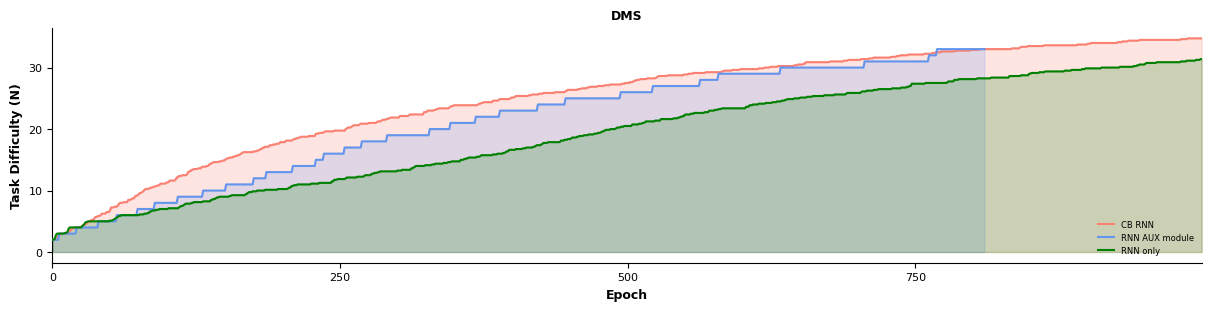

In [6]:
from analysis.single_task_plotting_utils import _collect_runs, average_and_plot_runs, average_and_plot_runs_multitask

single_task_DMS_DIR = RESULTS_DIR / "single_task/dms_multistyle_repeats"
# single_task_PARITY_DIR = RESULTS_DIR / "single_task/parity_multistyle_repeats"

groups = {
    "CB RNN": {
        "pattern": "gc256_RNNlr0.01_CBlr0.01_CBinput_simult_net",
        "color": "salmon"
    },
    "RNN AUX module": {
        "pattern": "single_dms_elman_size_64_auxH139_RNNlr0.01_CBlr0.01_CBinput_network",
        "color": "cornflowerblue"
    },
    "RNN only": {
        "pattern": "elman_size_202_noCB",
        "color": "green"
    },
}

task_dirs = {
    "DMS": single_task_DMS_DIR,
}

clip_lens = {
    "DMS": 1000,
}

clip_Ns = {
    "DMS": None,
}

task_titles = {
    "DMS": "DMS",
}

task_aggs1, fig, axs = average_and_plot_runs_multitask(
    task_dirs=task_dirs,
    groups=groups,
    clip_lens=clip_lens,
    clip_Ns=clip_Ns,
    task_titles=task_titles,
    figure_title="",
    plot_metric2="loss",
    plot_lower_metric=False,
    log_y2=True,
    figsize=(12, 3),
    sharey_top=False,
    shade_auc=True,
    fig_height=0.9,
    shade_sem=False,
    sharey_bottom=True,
    save_path=None
)


# Testing fixed N checkpoints

/Users/alex/anaconda3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


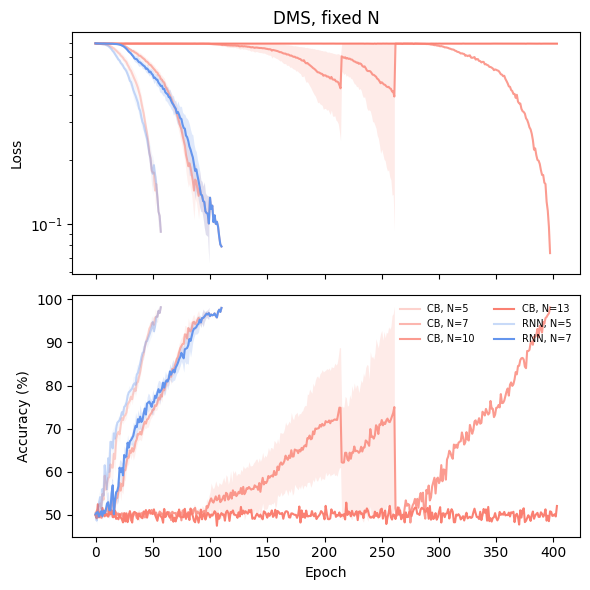

In [7]:
from analysis.single_task_analysis_utils import average_fixed_n_loss_acc, plot_fixed_n_comparison
fixed_N_DMS_DIR = RESULTS_DIR / "single_task/fixedN"
results_cb = average_fixed_n_loss_acc(fixed_N_DMS_DIR, "CB")
results_rnn = average_fixed_n_loss_acc(fixed_N_DMS_DIR, "noCB")   

fig, axs = plot_fixed_n_comparison(
    {"CB": results_cb, "RNN": results_rnn},
    title="DMS, fixed N",
)
